##### (A) Dataset Creation
# import libraries


In [50]:
import pandas as pd
import numpy as np


# install  Faker

In [51]:
%pip install faker


In [52]:
from faker import Faker

# Faker and define constants

In [53]:
fake = Faker()
num_employees = 500
departments = ["Sales", "HR", "IT", "Finance", "Marketing"]

# Generate data

In [54]:
data = {
    'Employee ID': [f'EMP{str(i).zfill(3)}' for i in range(1, num_employees + 1)],
    'Name': [fake.name() for _ in range(num_employees)],
    'Age': np.random.randint(22, 61, num_employees),
    'Gender': np.random.choice(['Male', 'Female'], num_employees),
    'Department': np.random.choice(departments, num_employees),
    'Salary': np.random.randint(40000, 120001, num_employees),
    'Years at Company': np.random.randint(1, 31, num_employees),
    'Performance Score': np.random.randint(1, 6, num_employees),
}

# Create DataFrame

In [55]:
df = pd.DataFrame(data)

# Add Promotion

In [56]:
df['Promotion Eligibility'] = np.where(df['Performance Score'] >= 4, 'Yes', 'No')


# Preview  dataset

In [57]:
df.head()

,Employee ID,Name,Age,Gender,Department,Salary,Years at Company,Performance Score,Promotion Eligibility
0,EMP001,Sylvia Wade,27,Male,IT,46764,1,1,No
1,EMP002,Benjamin Lopez,28,Male,Finance,60706,9,2,No
2,EMP003,Alyssa Anthony,30,Female,IT,100265,10,2,No
3,EMP004,Jessica Davis,35,Male,Finance,117744,5,3,No
4,EMP005,Trevor Waters,39,Female,Sales,42304,17,2,No


##### (B) Data Cleaning and Transformation
# Randomly set 10%

In [58]:
df.loc[df.sample(frac=0.1).index, 'Salary'] = np.nan


# Randomly set 5%

In [59]:
invalid_scores = df.sample(frac=0.05).index
df.loc[invalid_scores, 'Performance Score'] = np.random.choice([-1, 6], len(invalid_scores))


# Replace NaN salaries

In [60]:
df['Salary'] = df.groupby('Department')['Salary'].transform(lambda x: x.fillna(x.median()))


# Filter out invalid performance scores

In [61]:
df = df[(df['Performance Score'] >= 1) & (df['Performance Score'] <= 5)]

##### (C) Department-Wise Salary Analysis
# Group by department and calculate average salary

In [62]:
dept_salary_analysis = df.groupby('Department')['Salary'].agg(['mean', 'count'])
print(dept_salary_analysis)

                    mean  count
Department                     
Finance     84898.723810    105
HR          82773.434783     92
IT          76289.208333     96
Marketing   74381.522727     88
Sales       76253.127660     94


# Department with highest average

In [63]:
highest_salary_dept = dept_salary_analysis['mean'].idxmax()
print(f"Department with highest average salary: {highest_salary_dept}")


Department with highest average salary: Finance


# Average salary of employees eligible

In [64]:
eligible_salary = df[df['Promotion Eligibility'] == 'Yes']['Salary'].mean()
non_eligible_salary = df[df['Promotion Eligibility'] == 'No']['Salary'].mean()
print(f"Average salary (Eligible for promotion): {eligible_salary}")
print(f"Average salary (Not eligible): {non_eligible_salary}")

Average salary (Eligible for promotion): 78242.86549707603
Average salary (Not eligible): 79562.90789473684


# Boxplot of Salary distribution
##### matplotlib libray

In [65]:
import matplotlib.pyplot as plt

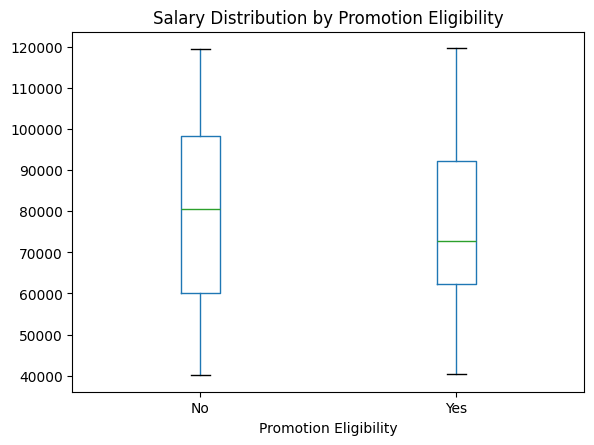

In [66]:
df.boxplot(column='Salary', by='Promotion Eligibility', grid=False)
plt.title('Salary Distribution by Promotion Eligibility')
plt.suptitle('')
plt.show()

# Scatter plot of Years at Company vs Salary

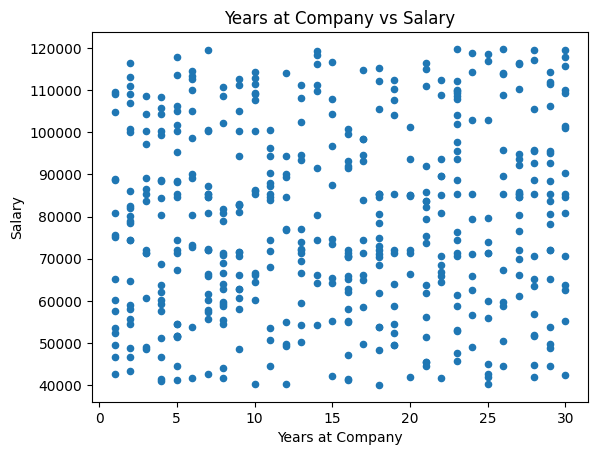

In [67]:
df.plot.scatter(x='Years at Company', y='Salary')
plt.title('Years at Company vs Salary')
plt.show()

# Histogram of age distribution by department

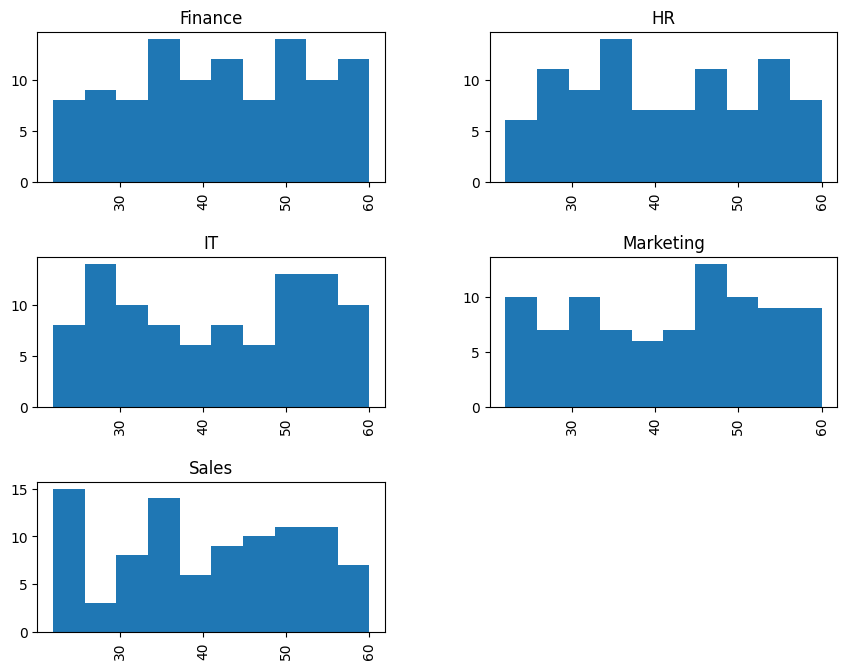

In [68]:
df['Age'].hist(by=df['Department'], bins=10, figsize=(10, 8))
plt.show()

##### (D) Dataset Visualization
# Bar chart

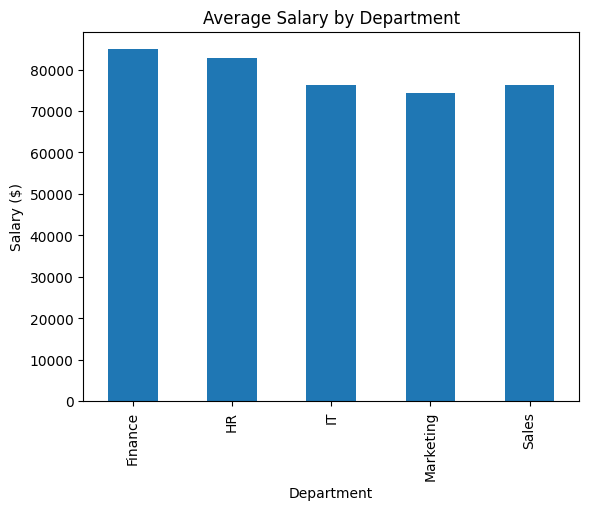

In [69]:
dept_salary_analysis['mean'].plot(kind='bar')
plt.title('Average Salary by Department')
plt.ylabel('Salary ($)')
plt.show()

# Line plot

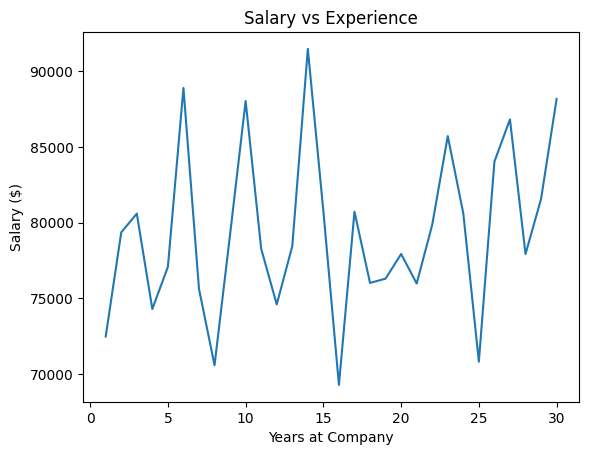

In [70]:
df.groupby('Years at Company')['Salary'].mean().plot(kind='line')
plt.title('Salary vs Experience')
plt.xlabel('Years at Company')
plt.ylabel('Salary ($)')
plt.show()

# Pie chart

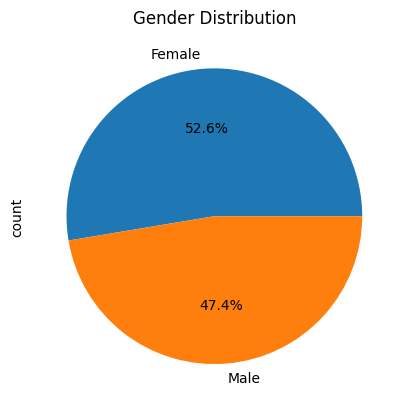

In [71]:
df['Gender'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Gender Distribution')
plt.show()

# Pie chart Promotion eligibility distribution

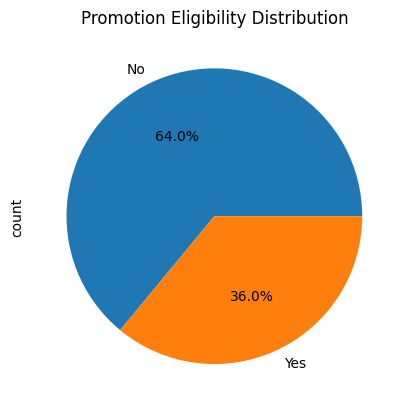

In [72]:
df['Promotion Eligibility'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Promotion Eligibility Distribution')
plt.show()

# Problem 02 
##### (A): Matrix and Vector Generation 
##### Generate random 5x5 matrix A and vector b

In [73]:
A = np.random.uniform(-10, 10, (5, 5))
b = np.random.uniform(-20, 20, 5)

print("Matrix A:\n", A)
print("Vector b:\n", b)

Matrix A:
 [[-0.89443154  9.55600928 -9.67816719 -9.58329222  0.31462377]
 [-9.47390555  7.47436296 -7.93204083 -6.81751439  5.02231461]
 [-3.21019242 -7.22657104  0.16961367  7.52614904 -5.54752296]
 [ 1.67518108 -3.56498956  2.95369032 -9.60299604  3.63471542]
 [-7.54971974 -5.18880746  9.59587121  7.82546939  0.18275189]]
Vector b:
 [13.99406708 12.91446196 13.96355333  7.89651362 -3.77040448]


##### (B) Solution Methods
# Explicit Inversion

In [74]:
x_inv = np.linalg.inv(A).dot(b)

# Recommended method

In [75]:
x_solve = np.linalg.solve(A, b)
print("Solution using Inversion:", x_inv)
print("Solution using np.linalg.solve():", x_solve)

Solution using Inversion: [-1.62625353 -1.27135498 -0.84856736 -1.79752452 -2.3844508 ]
Solution using np.linalg.solve(): [-1.62625353 -1.27135498 -0.84856736 -1.79752452 -2.3844508 ]


##### (C) Numerical Stability Analysis
# Condition number

In [76]:
condition_number = np.linalg.cond(A)
print("Condition number of A:", condition_number)


Condition number of A: 11.039306509454677


# Compare solutions

In [77]:
print("Difference between solutions:", np.linalg.norm(x_inv - x_solve))

Difference between solutions: 8.881784197001252e-16


##### (D) Advanced Visualizations


In [78]:
from mpl_toolkits.mplot3d import Axes3D


# 3D surface plot

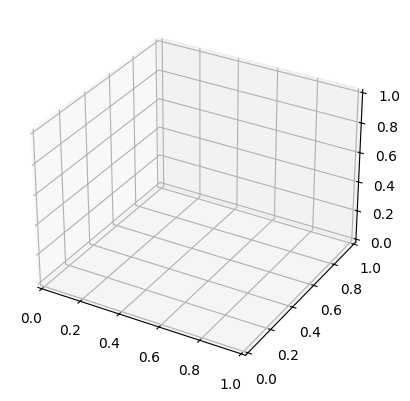

In [79]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')


# Create a grid for visualization

In [80]:
X, Y = np.meshgrid(np.arange(-10, 10, 1), np.arange(-10, 10, 1))
Z = A[0][0]*X + A[0][1]*Y + b[0]
ax.plot_surface(X, Y, Z, cmap='viridis')
plt.show()

# Heatmap of condition numbers for random matrices

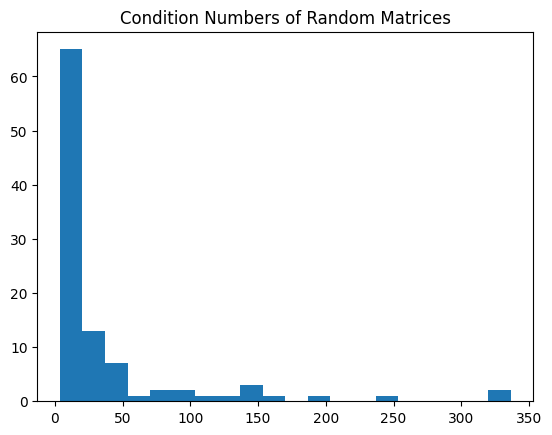

In [81]:
condition_numbers = [np.linalg.cond(np.random.uniform(-10, 10, (5, 5))) for _ in range(100)]
plt.hist(condition_numbers, bins=20)
plt.title('Condition Numbers of Random Matrices')
plt.show()

##### Problem 03
# Exploring Climate Data Visualizations
# Create climate dataset

In [82]:
years = np.arange(1970, 2021)
avg_temp = np.random.uniform(13, 16, len(years))
co2_levels = np.random.uniform(300, 420, len(years))
sea_level_rise = np.random.uniform(0, 100, len(years))

climate_data = pd.DataFrame({
    'Year': years,
    'Average Temperature (°C)': avg_temp,
    'CO2 Levels (ppm)': co2_levels,
    'Average Sea Level Rise (mm)': sea_level_rise
})

# Line plot for temperature and CO2 levels

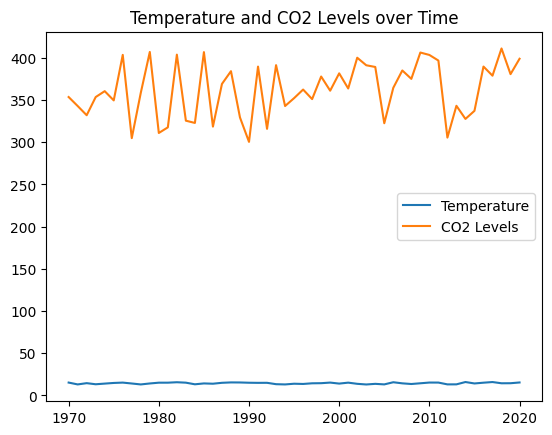

In [83]:
plt.plot(climate_data['Year'], climate_data['Average Temperature (°C)'], label='Temperature')
plt.plot(climate_data['Year'], climate_data['CO2 Levels (ppm)'], label='CO2 Levels')
plt.legend()
plt.title('Temperature and CO2 Levels over Time')
plt.show()


# Scatter plot of CO2 levels vs sea level rise with linear regression

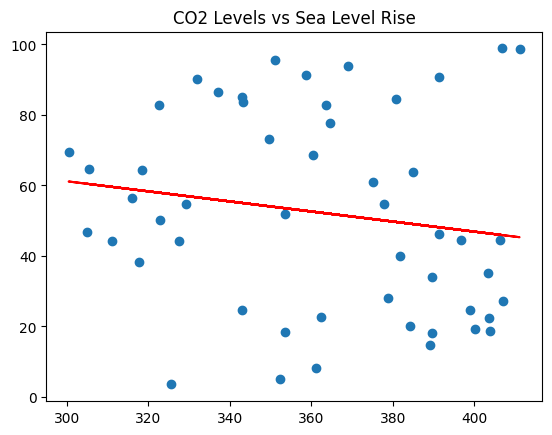

In [84]:
plt.scatter(climate_data['CO2 Levels (ppm)'], climate_data['Average Sea Level Rise (mm)'])
m, b = np.polyfit(climate_data['CO2 Levels (ppm)'], climate_data['Average Sea Level Rise (mm)'], 1)
plt.plot(climate_data['CO2 Levels (ppm)'], m*climate_data['CO2 Levels (ppm)'] + b, color='red')
plt.title('CO2 Levels vs Sea Level Rise')
plt.show()

# Histogram for average temperature

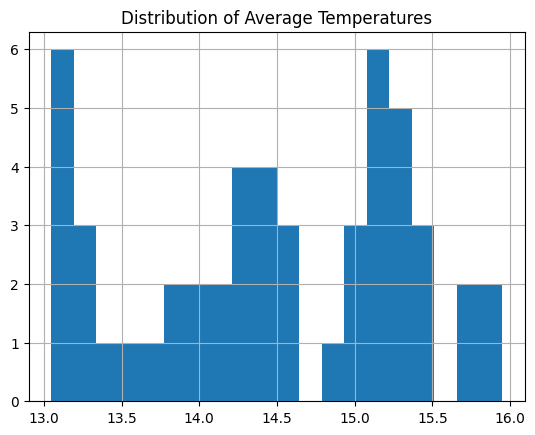

In [85]:
climate_data['Average Temperature (°C)'].hist(bins=20)
plt.title('Distribution of Average Temperatures')
plt.show()

# Box plot for sea level rise in two decades

C:\Users\ANSARI\AppData\Local\Temp\ipykernel_14612\2496088028.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([decade1, decade2], labels=['1970-1980', '2010-2020'])


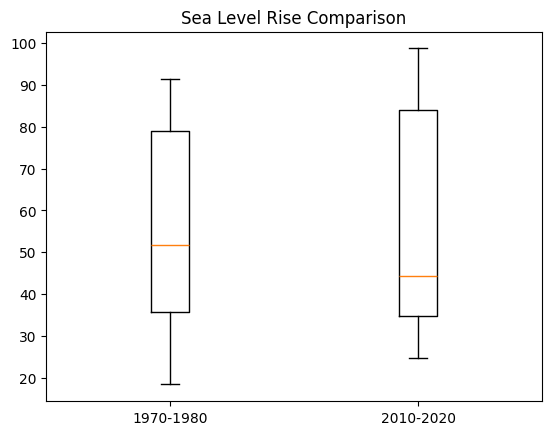

In [86]:
decade1 = climate_data[(climate_data['Year'] >= 1970) & (climate_data['Year'] <= 1980)]['Average Sea Level Rise (mm)']
decade2 = climate_data[(climate_data['Year'] >= 2010) & (climate_data['Year'] <= 2020)]['Average Sea Level Rise (mm)']
plt.boxplot([decade1, decade2], labels=['1970-1980', '2010-2020'])
plt.title('Sea Level Rise Comparison')
plt.show()

# Create correlation matrix

In [87]:
corr_matrix = climate_data.corr()

# Construct a heatmap
##### Install seaborn

In [88]:
%pip install seaborn


# import seaborn

In [89]:
import seaborn as sns


<Axes: >

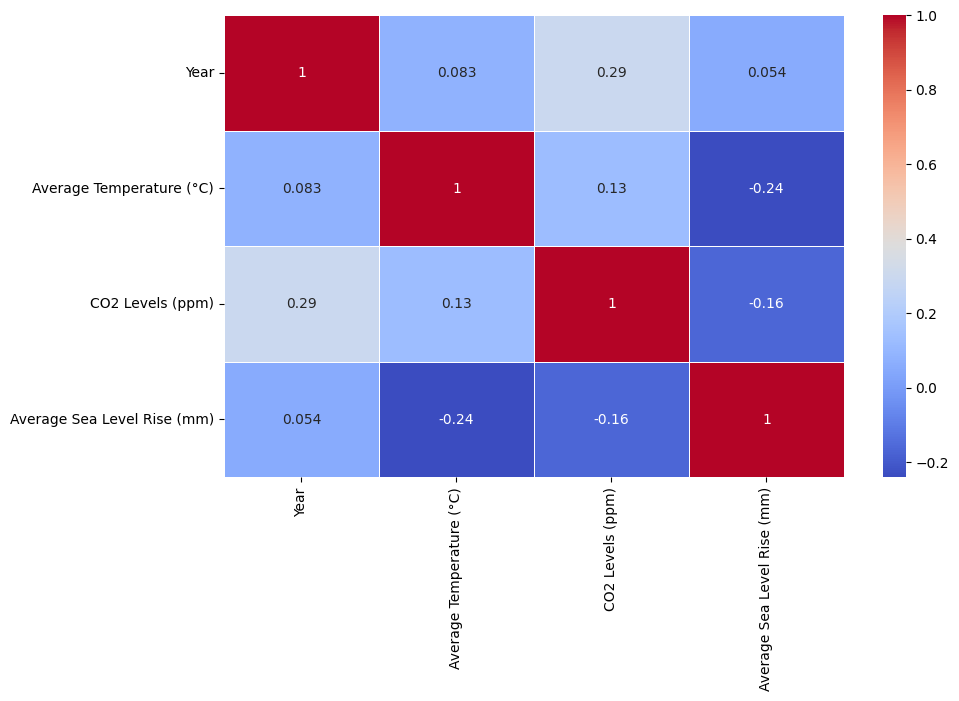

In [90]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)


# Highlight strong correlations

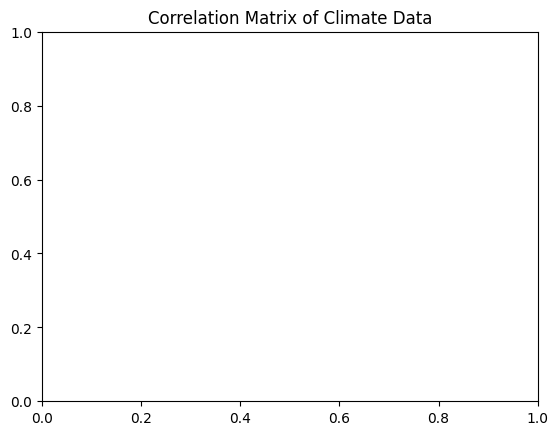

In [91]:
plt.title('Correlation Matrix of Climate Data')
plt.show()